# 01 — Baseline TF-IDF + LinearSVC

**Mục tiêu:** có một mốc *bắt buộc* trước khi dùng Transformer. Nếu Transformer không vượt được mốc này thì không đáng dùng.

Chạy xong notebook này sẽ có: kết quả khám phá dữ liệu (bước 1) và baseline (bước 2). Dữ liệu AG News tự tải qua `datasets` ở lần chạy đầu.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

MAX_TRAIN = None   # None = dùng đủ 120.000 mẫu train. Đặt vd. 5000 để chạy thử nhanh.

## Bước 1 — Nạp AG News, kiểm tra cân bằng lớp, xem 5 mẫu mỗi lớp

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 545de27e-a7c9-43cd-a031-9c2748c7ebb1)')' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 63f43ed6-f29e-49aa-bbbd-18cc98eaae71)')' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/main/README.md
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: bc0c2af6-90b7-4641-b889-29c4107c71e9)')' thrown while requesting HEAD https://huggingface.co/datasets/fancyzhx/ag_news/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(Proto

       số mẫu  World  Sports  Business  Sci/Tech
tập                                             
train  108000  27000   27000     27000     27000
val     12000   3000    3000      3000      3000
test     7600   1900    1900      1900      1900 

Số từ / tin (train): trung bình 38.0 · trung vị 37 · p95 53 · tối đa 171

=== World ===
  - Explosions caused mushroom cloud over N. Korea: source SEOUL, SOUTH KOREA - A mushroom-shaped cloud was seen in North Korea last Thursday following a …
  - Probe questions account given by British former home secretary in visa row (AFP) AFP - An official inquiry will show that former British home secretar…
  - Japan's homeless face ageism The number of Japanese homeless is on the rise, and cultural attitudes about age are exacerbating the situation.
  - Asia-Pacific partners fight terror, nuclear spread, trade barriers SANTIAGO (AFP) - US Secretary of State Colin Powell and partners in the Asia-Pacifi…
  - Koizumi Replaces Key Ministers Prime Minister J

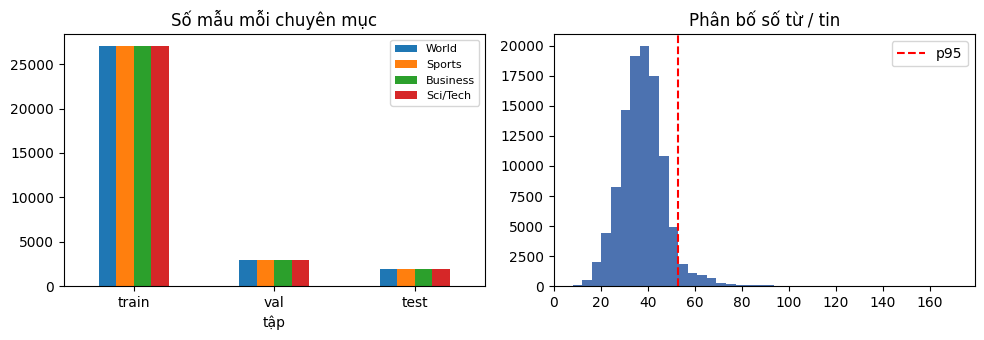

In [2]:
from data import load_ag_news, explore

data = load_ag_news(MAX_TRAIN)
explore(data);

Dữ liệu cân bằng hoàn toàn nên **accuracy** là thước đo hợp lý (vẫn báo cáo thêm F1-macro).
Tập validation (10% của train) chỉ dùng để chọn checkpoint/hiệu chỉnh xác suất; tập test chỉ dùng để báo cáo cuối.

## Bước 2 — Baseline TF-IDF (1–2 gram) + LinearSVC

In [3]:
import baseline

kq = baseline.run(data)

Val acc 0.9302 | Test acc 0.9258 | F1-macro 0.9256 | train 255.9s | 12.95 ms/tin
              precision    recall  f1-score   support

       World     0.9410    0.9068    0.9236      1900
      Sports     0.9566    0.9853    0.9707      1900
    Business     0.9007    0.8974    0.8990      1900
    Sci/Tech     0.9046    0.9137    0.9091      1900

    accuracy                         0.9258      7600
   macro avg     0.9257    0.9258    0.9256      7600
weighted avg     0.9257    0.9258    0.9256      7600



### Từ/cụm từ có trọng số lớn nhất cho mỗi chuyên mục
Giúp hiểu vì sao baseline mạnh: chủ đề tin tức gần như được quyết định bởi **từ khoá**, không cần hiểu thứ tự hay ngữ cảnh sâu.

In [4]:
import joblib
import numpy as np
from config import CLASSES, MODELS

b = joblib.load(MODELS / "tfidf_svc.joblib")
names = np.array(b["vectorizer"].get_feature_names_out())
for k, c in enumerate(CLASSES):
    print(f"{c:9s}:", ", ".join(names[np.argsort(b["model"].coef_[k])[-10:][::-1]]))

World    : iraq, canadian press, afp afp, afp, york stocks, iraqi, president, nuclear, iran, un
Sports   : coach, sports, cup, team, baseball, players, league, olympic, stadium, nascar
Business : tax, hellip, oil, economy, airlines, bank, enron, insurance, economic, investors
Sci/Tech : space, nasa, internet, scientists, linux, apple, software, web, online, microsoft


**Ghi lại:** accuracy ở trên là mốc để so sánh với Transformer tự xây (notebook 02) và DistilBERT (notebook 03). Kết quả được lưu trong `reports/` để notebook 04 tổng hợp.